<a href="https://colab.research.google.com/github/agatastachowiak/wearable-stress-detection/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# Download the dataset
os.makedirs('/root/wesad_data', exist_ok=True)
!wget -O /root/wesad_data/WESAD.zip "https://uni-siegen.sciebo.de/s/HGdUkoNlW1Ub0Gx/download"

# Unzip it
!unzip -q /root/wesad_data/WESAD.zip -d /root/wesad_data/

--2026-09-08 10:21:00--  https://uni-siegen.sciebo.de/s/HGdUkoNlW1Ub0Gx/download
Resolving uni-siegen.sciebo.de (uni-siegen.sciebo.de)... 128.176.1.4
Connecting to uni-siegen.sciebo.de (uni-siegen.sciebo.de)|128.176.1.4|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://uni-siegen.sciebo.de/public.php/dav/files/HGdUkoNlW1Ub0Gx [following]
--2026-09-08 10:21:01--  https://uni-siegen.sciebo.de/public.php/dav/files/HGdUkoNlW1Ub0Gx
Reusing existing connection to uni-siegen.sciebo.de:443.
HTTP request sent, awaiting response... 200 OK
Length: 2249444501 (2.1G) [application/zip]
Saving to: ‘/root/wesad_data/WESAD.zip’

/root/wesad_data/WE 100%[===================>]   2.09G  23.4MB/s    in 1m 48s  

2026-09-08 10:22:49 (19.9 MB/s) - ‘/root/wesad_data/WESAD.zip’ saved [2249444501/2249444501]



Dataset: WESAD (Wearable Stress and Affect Detection):
public dataset where participants wore both a chest-worn device and a wrist-worn device while going through different conditions in a lab setting: a neutral baseline period, a stress-inducing task (public speaking / mental arithmetic under time pressure — a standard stress-induction protocol used in psychology research), and an amusement period (watching funny video clips).

In [2]:
# List what's inside
for item in sorted(os.listdir('/root/wesad_data/WESAD')):
    print(item)

S10
S11
S13
S14
S15
S16
S17
S2
S3
S4
S5
S6
S7
S8
S9
wesad_readme.pdf


In [5]:
# Load wesad_readme.pdf
!pip install pdfplumber -q

import pdfplumber

with pdfplumber.open('/root/wesad_data/WESAD/wesad_readme.pdf') as pdf:
    for i, page in enumerate(pdf.pages):
        print(f"--- Page {i+1} ---")
        print(page.extract_text())
        print()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 70.4 MB/s eta 0:00:00
--- Page 1 ---
WESAD Dataset: WEarable Stress and Affect Detection
I. General information
Contact persons: Philip Schmidt and Attila Reiss, contact at: firstname.lastname@de.bosch.com.
If you publish material based on this dataset, please reference the publication [1].
I.1. Dataset structure
The dataset is organised so that each subject has a folder (SX, where X = subject ID). Each subject
folder contains the following files:
- SX_readme.txt: contains information about the subject (SX) and information about data collection
an

In [3]:
# Load one subject and inspect the structure
import pickle

with open('/root/wesad_data/WESAD/S2/S2.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print("Top-level keys:", data.keys())
print("Signal keys:", data['signal'].keys())
print("Wrist signal keys:", data['signal']['wrist'].keys())
print("Label array shape:", data['label'].shape)
print("Unique labels:", set(data['label']))

Top-level keys: dict_keys(['signal', 'label', 'subject'])
Signal keys: dict_keys(['chest', 'wrist'])
Wrist signal keys: dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])
Label array shape: (4255300,)
Unique labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(6), np.int32(7)}


15 subject folders

signal has chest and wrist — both devices' recordings are present; for this project the focus will stay on **wrist** only (to mirror real consumer wearables)

Wrist signal keys:

ACC = accelerometer (movement, 3-axis)

BVP = Blood Volume Pulse (used to derive heart rate)

EDA = Electrodermal Activity (skin conductance — key "stress" signal)

TEMP = skin temperature

Unique labels: {0, 1, 2, 3, 4, 6, 7}

0 = not defined / transient (transitions between conditions, or before the study properly started)
1 = baseline
2 = stress
3 = amusement
4 = meditation
6, 7 = additional experimental conditions specific to the study protocol (recovery periods, etc.)

For this project focus on labels 1, 2, and 3 (baseline / stress / amusement).

In [4]:
#confirm this label mapping and look at one signal

# Check how much data exists for each label -- sanity-check
import numpy as np

labels = data['label']
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Label {u}: {c} samples")

Label 0: 2142701 samples
Label 1: 800800 samples
Label 2: 430500 samples
Label 3: 253400 samples
Label 4: 537599 samples
Label 6: 45500 samples
Label 7: 44800 samples


EDA wrist signal shape: (24316, 1)


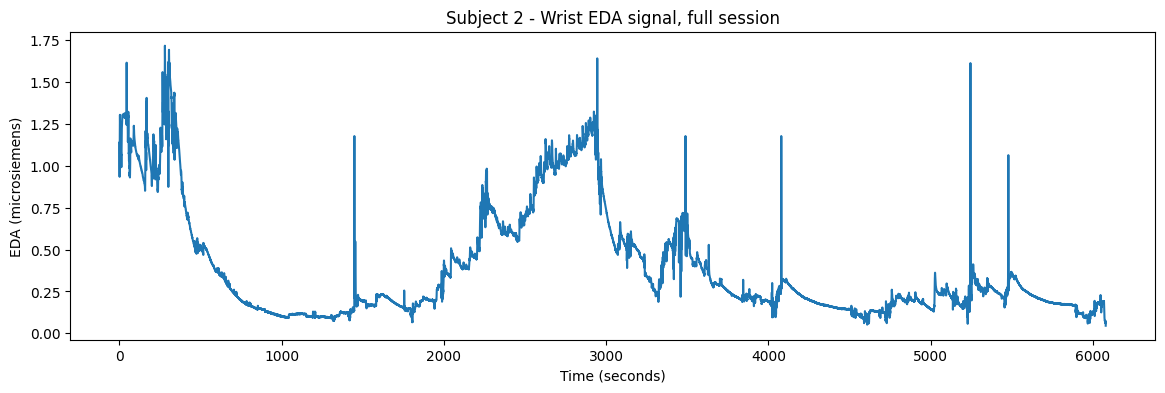

In [6]:
import matplotlib.pyplot as plt
import numpy as np

eda_wrist = data['signal']['wrist']['EDA']
print("EDA wrist signal shape:", eda_wrist.shape)

eda_time = np.arange(len(eda_wrist)) / 4.0  # 4 Hz sampling rate, confirmed by the readme

plt.figure(figsize=(14, 4))
plt.plot(eda_time, eda_wrist)
plt.xlabel('Time (seconds)')
plt.ylabel('EDA (microsiemens)')
plt.title('Subject 2 - Wrist EDA signal, full session')
plt.show()

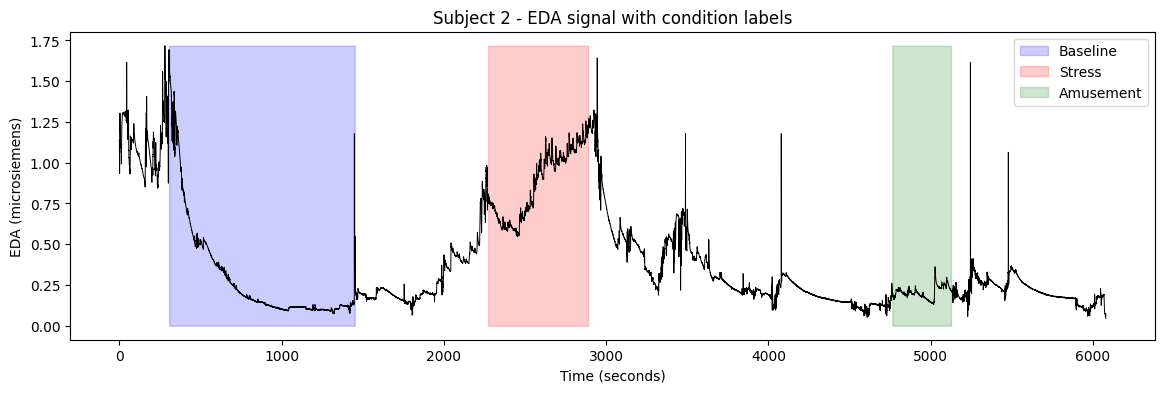

In [7]:
# Align labels to this signal properly

labels = data['label']  # sampled at 700 Hz
label_time = np.arange(len(labels)) / 700.0  # time axis for labels, in seconds

# Downsample labels to match the label's timepoints onto the EDA plot as background shading
plt.figure(figsize=(14, 4))
plt.plot(eda_time, eda_wrist, color='black', linewidth=0.7)

# Shade regions by condition: baseline=blue, stress=red, amusement=green
colors = {1: ('blue', 'Baseline'), 2: ('red', 'Stress'), 3: ('green', 'Amusement')}
for label_val, (color, name) in colors.items():
    mask = labels == label_val
    plt.fill_between(label_time, 0, eda_wrist.max(), where=mask, color=color, alpha=0.2, label=name)

plt.xlabel('Time (seconds)')
plt.ylabel('EDA (microsiemens)')
plt.title('Subject 2 - EDA signal with condition labels')
plt.legend()
plt.show()

Baseline window - it starts elevated (probably early sensor-settling noise) and steadily declines through the window, reaching a genuinely calm plateau by the end of the baseline period. So, EDA gradually settles as a person relaxes.

Stress window - the rising portion of the signal;  EDA climbs steadily through the stress window, peaking right as the stress condition ends. Skin conductance rising during evaluative, high-pressure tasks like public speaking and mental arithmetic.

Amusement window - sits in a moderate, bumpy-but-lower region, noticeably calmer than stress, consistent with amusement being a positive but less physiologically intense state than acute stress.